In [34]:
import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import os
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import seaborn as sns
import folium
from folium.plugins import HeatMap
import glob
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from sklearn.metrics import pairwise_distances
from scipy.linalg import sqrtm
from scipy.special import digamma, loggamma
from math import pi

In [6]:
Advan = pd.read_csv('/Users/sankalpyadava/Desktop/Biocomplexity Institute/InDepth_AdvanData.csv')

ParserError: Error tokenizing data. C error: Expected 52 fields in line 1170730, saw 79


In [7]:
with open('/Users/sankalpyadava/Desktop/Biocomplexity Institute/InDepth_AdvanData.csv') as f:
    for i, line in enumerate(f):
        if i == 1170729:  # 0-indexed, so line 1170730
            print(line)
            break

22t-223@5x2-zkw-v2k,,,Adult Counseling,,,Offices of Physicians,Offices of Physicians (except Mental Health Specialists),621111,48.421552,-122.337492,117 N 1st St Ste 54,Mount Vernon,WA,98273,,,,,2019-07,,POLYGON,"POLYGON ((-122.33720711899997 48.42177956300003, -122.33720445199998 48.421336773000064, -122.33773617399999 48.42133529500006, -122.33773884399994 48.42177808500003, -122.33720711899997 48.42177956300003))",SHARED_POLYGON,False,13603363721.0,False,False,US,1937.0,2024-09-23T00:00:00-08:00,2024-09-30T00:00:00-08:00,74.0,50.0,"[11,14,12,12,11,9,5]","[0,0,0,0,0,0,0,0,0,11,0,0,11,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5,0,0,0,0,5,0,0,0,0,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,12,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,1,1,2,1,1,1,1,1,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5,5,5,5,0,5,0,0,0]",530579525003,"{""530579523021"":6,""530579518001"":6,""530579517001"":6,""530579525001"":6}"

In [8]:
bad_line_count = 0
bad_line_numbers = []

with open('/Users/sankalpyadava/Desktop/Biocomplexity Institute/InDepth_AdvanData.csv') as f:
    header_fields = len(f.readline().split(','))
    for i, line in enumerate(f):
        n_fields = len(line.split(','))
        if n_fields != header_fields:
            bad_line_count += 1
            bad_line_numbers.append(i + 2)

print(bad_line_count, bad_line_numbers[:20])

1170734 [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]


In [10]:
import csv
import sys

csv.field_size_limit(sys.maxsize)

bad_line_count = 0
bad_line_numbers = []

with open('/Users/sankalpyadava/Desktop/Biocomplexity Institute/InDepth_AdvanData.csv') as f:
    reader = csv.reader(f)
    header_fields = len(next(reader))
    for i, row in enumerate(reader):
        if len(row) != header_fields:
            bad_line_count += 1
            bad_line_numbers.append(i + 2)

print(bad_line_count, bad_line_numbers[:20])

3 [1170730, 1170734, 1170735]


In [11]:
target_lines = {1170730, 1170734, 1170735}

with open('/Users/sankalpyadava/Desktop/Biocomplexity Institute/InDepth_AdvanData.csv') as f:
    for i, line in enumerate(f, start=1):
        if i in target_lines:
            print(f"--- line {i} ---")
            print(line)
            print()

--- line 1170730 ---
22t-223@5x2-zkw-v2k,,,Adult Counseling,,,Offices of Physicians,Offices of Physicians (except Mental Health Specialists),621111,48.421552,-122.337492,117 N 1st St Ste 54,Mount Vernon,WA,98273,,,,,2019-07,,POLYGON,"POLYGON ((-122.33720711899997 48.42177956300003, -122.33720445199998 48.421336773000064, -122.33773617399999 48.42133529500006, -122.33773884399994 48.42177808500003, -122.33720711899997 48.42177956300003))",SHARED_POLYGON,False,13603363721.0,False,False,US,1937.0,2024-09-23T00:00:00-08:00,2024-09-30T00:00:00-08:00,74.0,50.0,"[11,14,12,12,11,9,5]","[0,0,0,0,0,0,0,0,0,11,0,0,11,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5,0,0,0,0,5,0,0,0,0,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,12,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,1,1,2,1,1,1,1,1,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5,5,5,5,0,5,0,0,0]",530579525003,"{""530579523021"":6,""530579518001"":6,""530579517001"":6

In [3]:
Advan = pd.read_csv(
    '/Users/sankalpyadava/Desktop/Biocomplexity Institute/InDepth_AdvanData.csv',
    on_bad_lines='skip',
    engine='python'
)
print(len(Advan))

1170719


In [4]:
print(Advan.columns)

Index(['placekey', 'parent_placekey', 'safegraph_brand_ids', 'location_name',
       'brands', 'store_id', 'top_category', 'sub_category', 'naics_code',
       'latitude', 'longitude', 'street_address', 'city', 'region',
       'postal_code', 'open_hours', 'category_tags', 'opened_on', 'closed_on',
       'tracking_closed_since', 'websites', 'geometry_type', 'polygon_wkt',
       'polygon_class', 'enclosed', 'phone_number', 'is_synthetic',
       'includes_parking_lot', 'iso_country_code', 'wkt_area_sq_meters',
       'date_range_start', 'date_range_end', 'raw_visit_counts',
       'raw_visitor_counts', 'visits_by_day', 'visits_by_each_hour', 'poi_cbg',
       'visitor_home_cbgs', 'visitor_home_aggregation', 'visitor_daytime_cbgs',
       'visitor_country_of_origin', 'distance_from_home', 'median_dwell',
       'bucketed_dwell_times', 'related_same_day_brand',
       'related_same_week_brand', 'device_type',
       'normalized_visits_by_state_scaling',
       'normalized_visits_by_regi

In [56]:
Advan['poi_cbg'] = Advan['poi_cbg'].astype(str).str.zfill(12)
Advan['naics2'] = Advan['naics_code'].astype(str).str[:2]
Advan['county'] = Advan['poi_cbg'].str[2:5]
Advan_VA = Advan[Advan['poi_cbg'].str[:2] == '51'].copy()

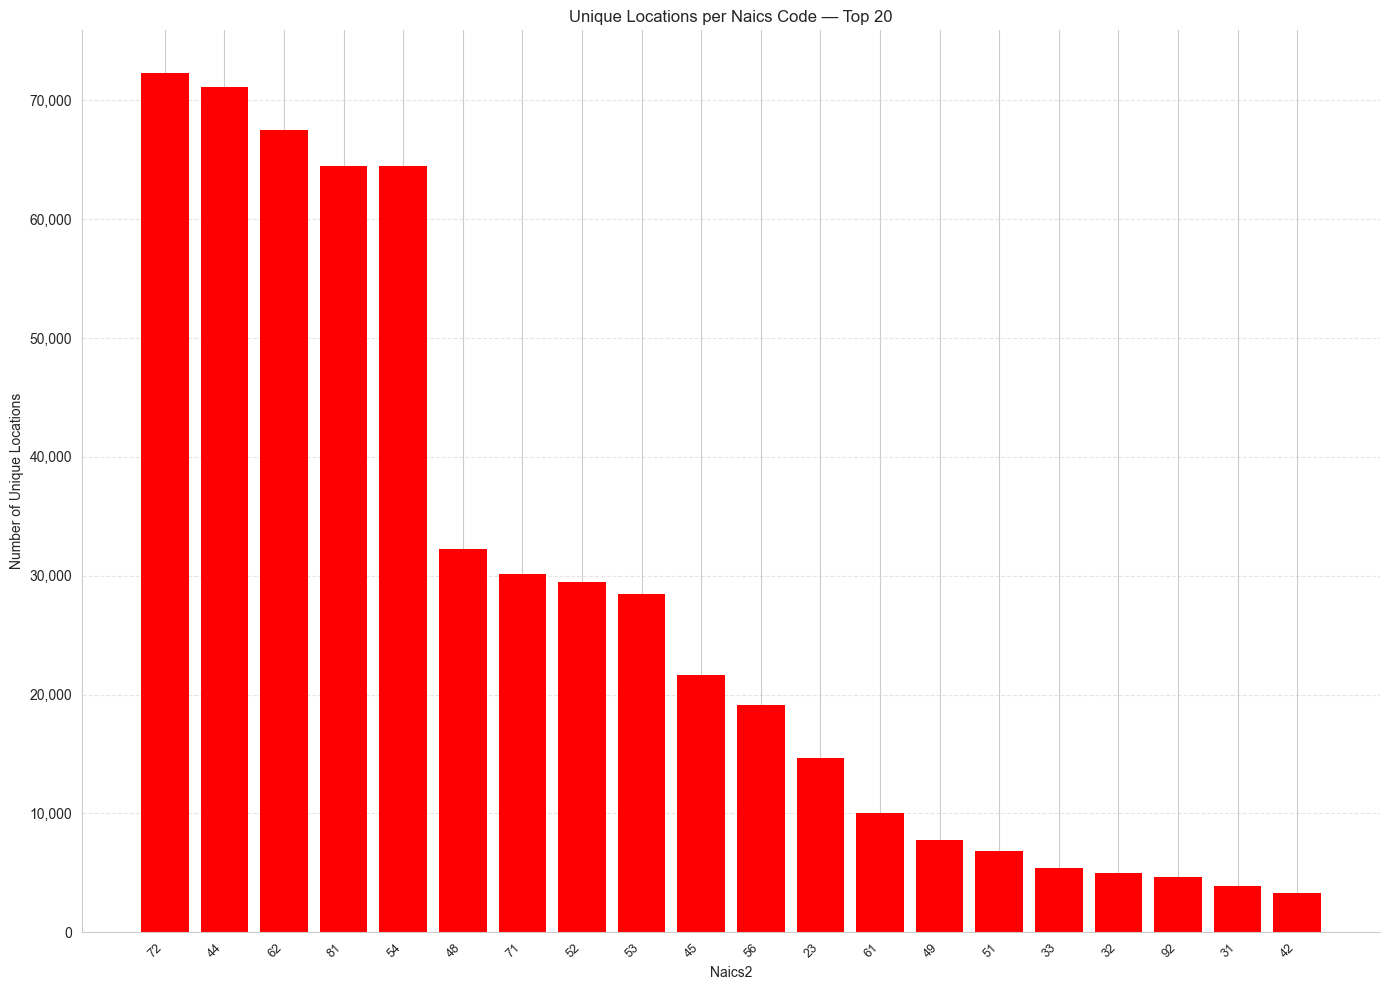

In [60]:
import matplotlib.pyplot as plt

top20 = (Advan.groupby('naics2')['placekey']
         .nunique()
         .nlargest(20)
         .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(14, 10))

ax.bar(range(len(top20)), top20.values, color='red', edgecolor='none')

ax.set_xticks(range(len(top20)))
ax.set_xticklabels(top20.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Number of Unique Locations')
ax.set_xlabel('Naics2')
ax.set_title('Unique Locations per Naics Code — Top 20')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

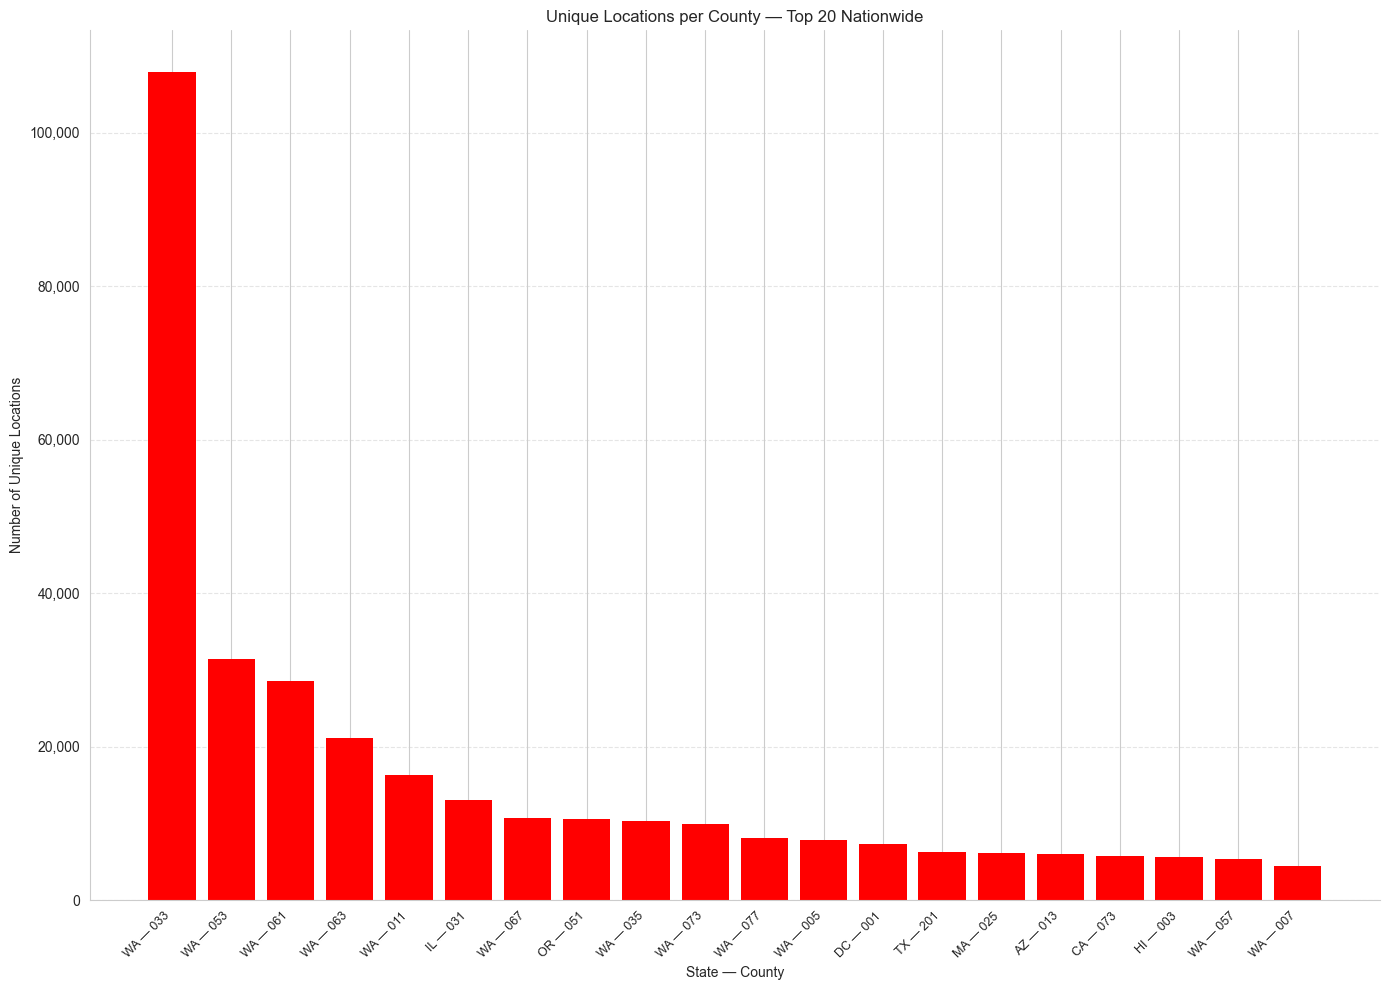

In [62]:
import matplotlib.pyplot as plt

Advan['state_fips'] = Advan['poi_cbg'].astype(str).str.zfill(12).str[:2]

state_fips_map = {
    '01': 'AL', '02': 'AK', '04': 'AZ', '05': 'AR', '06': 'CA', '08': 'CO',
    '09': 'CT', '10': 'DE', '11': 'DC', '12': 'FL', '13': 'GA', '15': 'HI',
    '16': 'ID', '17': 'IL', '18': 'IN', '19': 'IA', '20': 'KS', '21': 'KY',
    '22': 'LA', '23': 'ME', '24': 'MD', '25': 'MA', '26': 'MI', '27': 'MN',
    '28': 'MS', '29': 'MO', '30': 'MT', '31': 'NE', '32': 'NV', '33': 'NH',
    '34': 'NJ', '35': 'NM', '36': 'NY', '37': 'NC', '38': 'ND', '39': 'OH',
    '40': 'OK', '41': 'OR', '42': 'PA', '44': 'RI', '45': 'SC', '46': 'SD',
    '47': 'TN', '48': 'TX', '49': 'UT', '50': 'VT', '51': 'VA', '53': 'WA',
    '54': 'WV', '55': 'WI', '56': 'WY'
}

Advan['state_abbr'] = Advan['state_fips'].map(state_fips_map)
Advan['state_county'] = Advan['state_abbr'] + ' — ' + Advan['county']

top20 = (Advan.drop_duplicates(subset='placekey')
            .groupby('state_county')['placekey']
            .nunique()
            .nlargest(20)
            .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(14, 10))

ax.bar(range(len(top20)), top20.values, color='red', edgecolor='none')

ax.set_xticks(range(len(top20)))
ax.set_xticklabels(top20.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Number of Unique Locations')
ax.set_xlabel('State — County')
ax.set_title('Unique Locations per County — Top 20 Nationwide')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [48]:
FirstAdvan = pd.read_csv('/Users/sankalpyadava/Desktop/Biocomplexity Institute/Advan.csv')

In [69]:
print(FirstAdvan.shape)
print(Advan.shape)
print(Advan_VA.shape)

print(set(FirstAdvan.columns) - set(Advan.columns))
print(set(Advan.columns) - set(FirstAdvan.columns))

(4761, 63)
(1170719, 57)
(4308, 54)
{'Tue', 'Fri', 'Sat', 'Wed', 'week_start', 'Sun', 'census_tract', 'Mon', 'Thu'}
{'state_fips', 'state_abbr', 'state_county'}


In [51]:
print("Total rows — Advan_VA:", len(Advan_VA))
print("Total rows — FirstAdvan:", len(FirstAdvan))

print("Unique placekeys — Advan_VA:", Advan_VA['placekey'].nunique())
print("Unique placekeys — FirstAdvan:", FirstAdvan['placekey'].nunique())

Advan_VA['naics2'] = Advan_VA['naics2'].astype(str)
FirstAdvan['naics2'] = FirstAdvan['naics2'].astype(str)
Advan_VA['county'] = Advan_VA['county'].astype(str)
FirstAdvan['county'] = FirstAdvan['county'].astype(str)

naics2_advan_va = Advan_VA.drop_duplicates(subset='placekey')['naics2'].value_counts()
naics2_FirstAdvan = FirstAdvan.drop_duplicates(subset='placekey')['naics2'].value_counts()

naics2_compare = pd.DataFrame({
    'Advan_VA': naics2_advan_va,
    'FirstAdvan': naics2_FirstAdvan
}).fillna(0).astype(int)
naics2_compare['diff'] = naics2_compare['FirstAdvan'] - naics2_compare['Advan_VA']

county_advan_va = Advan_VA.drop_duplicates(subset='placekey')['county'].value_counts()
county_FirstAdvan = FirstAdvan.drop_duplicates(subset='placekey')['county'].value_counts()

county_compare = pd.DataFrame({
    'Advan_VA': county_advan_va,
    'FirstAdvan': county_FirstAdvan
}).fillna(0).astype(int)
county_compare['diff'] = county_compare['FirstAdvan'] - county_compare['Advan_VA']

print(naics2_compare.sort_values('FirstAdvan', ascending=False))
print(county_compare.sort_values('FirstAdvan', ascending=False))

Total rows — Advan_VA: 4308
Total rows — FirstAdvan: 4761
Unique placekeys — Advan_VA: 3552
Unique placekeys — FirstAdvan: 3806
        Advan_VA  FirstAdvan  diff
naics2                            
62           495         566    71
54           307         560   253
72           558         521   -37
44           480         514    34
53           255         319    64
81           366         294   -72
71           256         206   -50
52           129         147    18
45           148         146    -2
56           119         121     2
48           117         108    -9
61            66          79    13
23            73          57   -16
51            61          51   -10
33            28          26    -2
32            24          23    -1
92            23          18    -5
49            14          16     2
31            13          14     1
42            11          11     0
55             9           9     0
        Advan_VA  FirstAdvan  diff
county                          

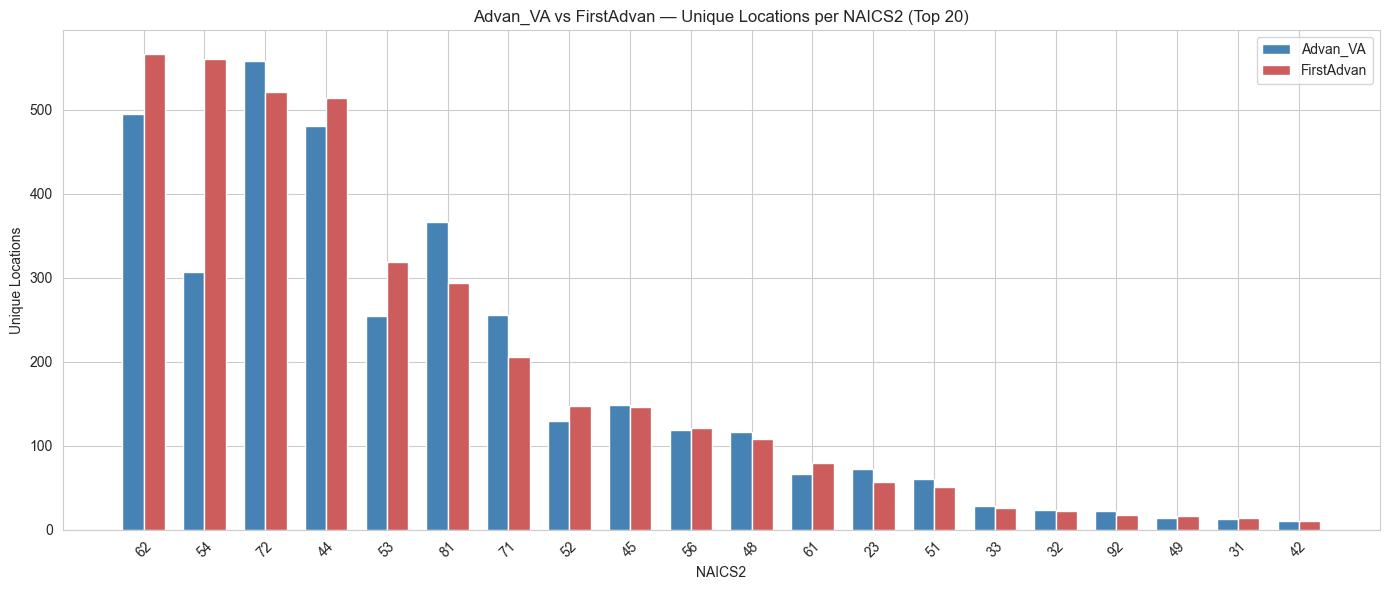

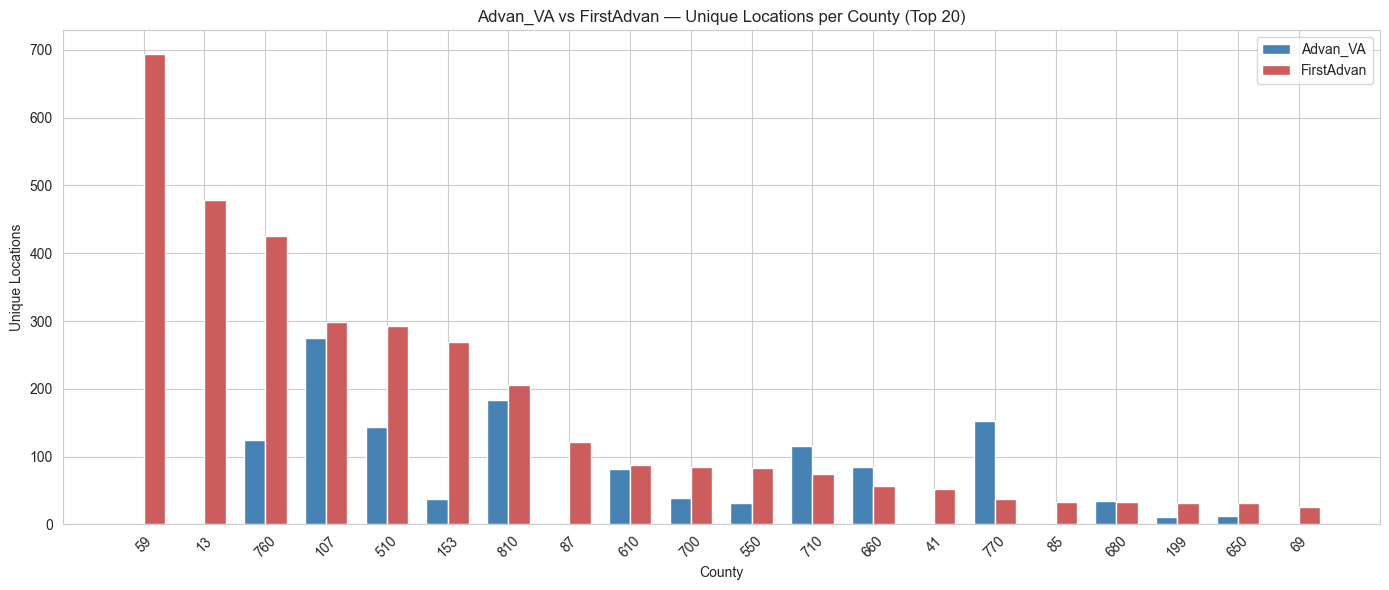

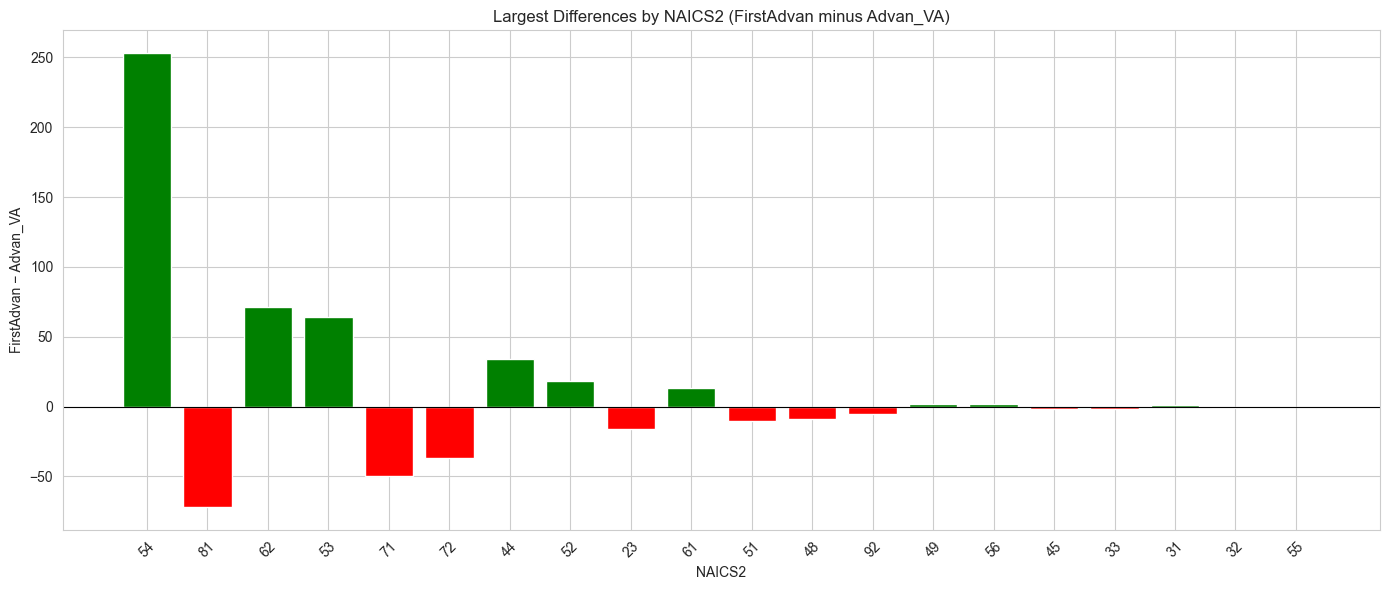

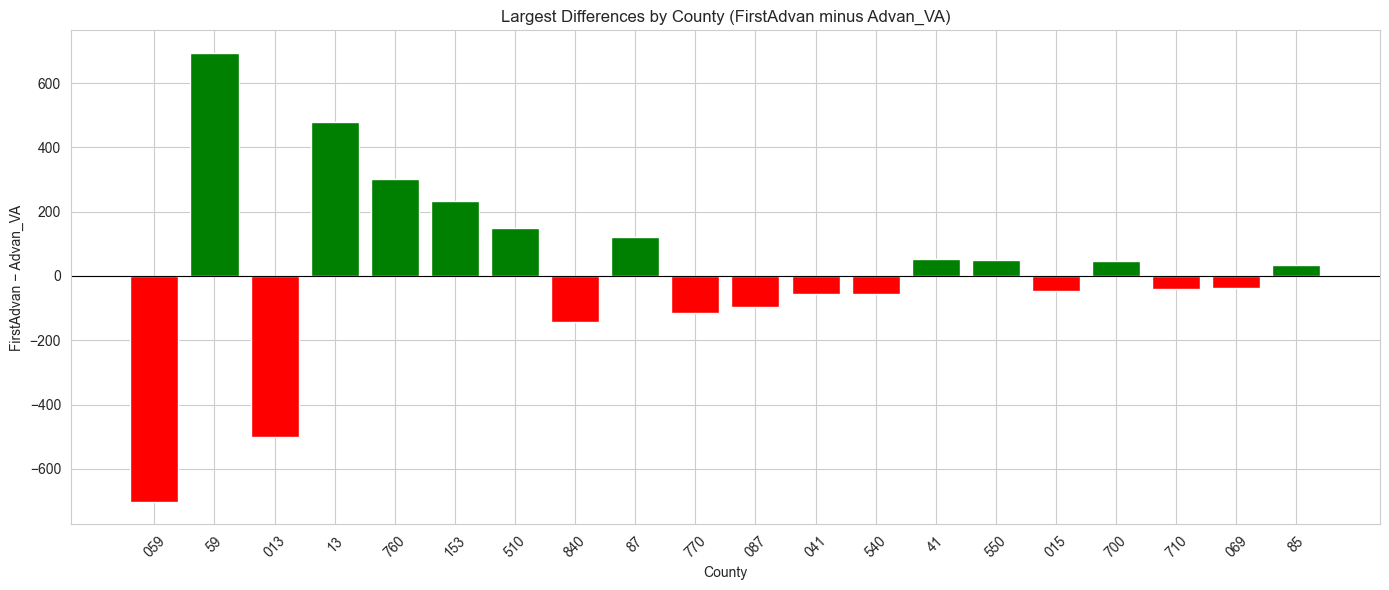

In [52]:
naics2_top = naics2_compare.sort_values('FirstAdvan', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(naics2_top))
width = 0.35
ax.bar([i - width/2 for i in x], naics2_top['Advan_VA'], width, label='Advan_VA', color='steelblue')
ax.bar([i + width/2 for i in x], naics2_top['FirstAdvan'], width, label='FirstAdvan', color='indianred')
ax.set_xticks(list(x))
ax.set_xticklabels(naics2_top.index, rotation=45)
ax.set_xlabel('NAICS2')
ax.set_ylabel('Unique Locations')
ax.set_title('Advan_VA vs FirstAdvan — Unique Locations per NAICS2 (Top 20)')
ax.legend()
plt.tight_layout()
plt.show()

county_top = county_compare.sort_values('FirstAdvan', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(county_top))
ax.bar([i - width/2 for i in x], county_top['Advan_VA'], width, label='Advan_VA', color='steelblue')
ax.bar([i + width/2 for i in x], county_top['FirstAdvan'], width, label='FirstAdvan', color='indianred')
ax.set_xticks(list(x))
ax.set_xticklabels(county_top.index, rotation=45)
ax.set_xlabel('County')
ax.set_ylabel('Unique Locations')
ax.set_title('Advan_VA vs FirstAdvan — Unique Locations per County (Top 20)')
ax.legend()
plt.tight_layout()
plt.show()

naics2_diff_sorted = naics2_compare.reindex(naics2_compare['diff'].abs().sort_values(ascending=False).index).head(20)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['green' if v > 0 else 'red' for v in naics2_diff_sorted['diff']]
ax.bar(naics2_diff_sorted.index.astype(str), naics2_diff_sorted['diff'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('NAICS2')
ax.set_ylabel('FirstAdvan − Advan_VA')
ax.set_title('Largest Differences by NAICS2 (FirstAdvan minus Advan_VA)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

county_diff_sorted = county_compare.reindex(county_compare['diff'].abs().sort_values(ascending=False).index).head(20)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['green' if v > 0 else 'red' for v in county_diff_sorted['diff']]
ax.bar(county_diff_sorted.index.astype(str), county_diff_sorted['diff'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('County')
ax.set_ylabel('FirstAdvan − Advan_VA')
ax.set_title('Largest Differences by County (FirstAdvan minus Advan_VA)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

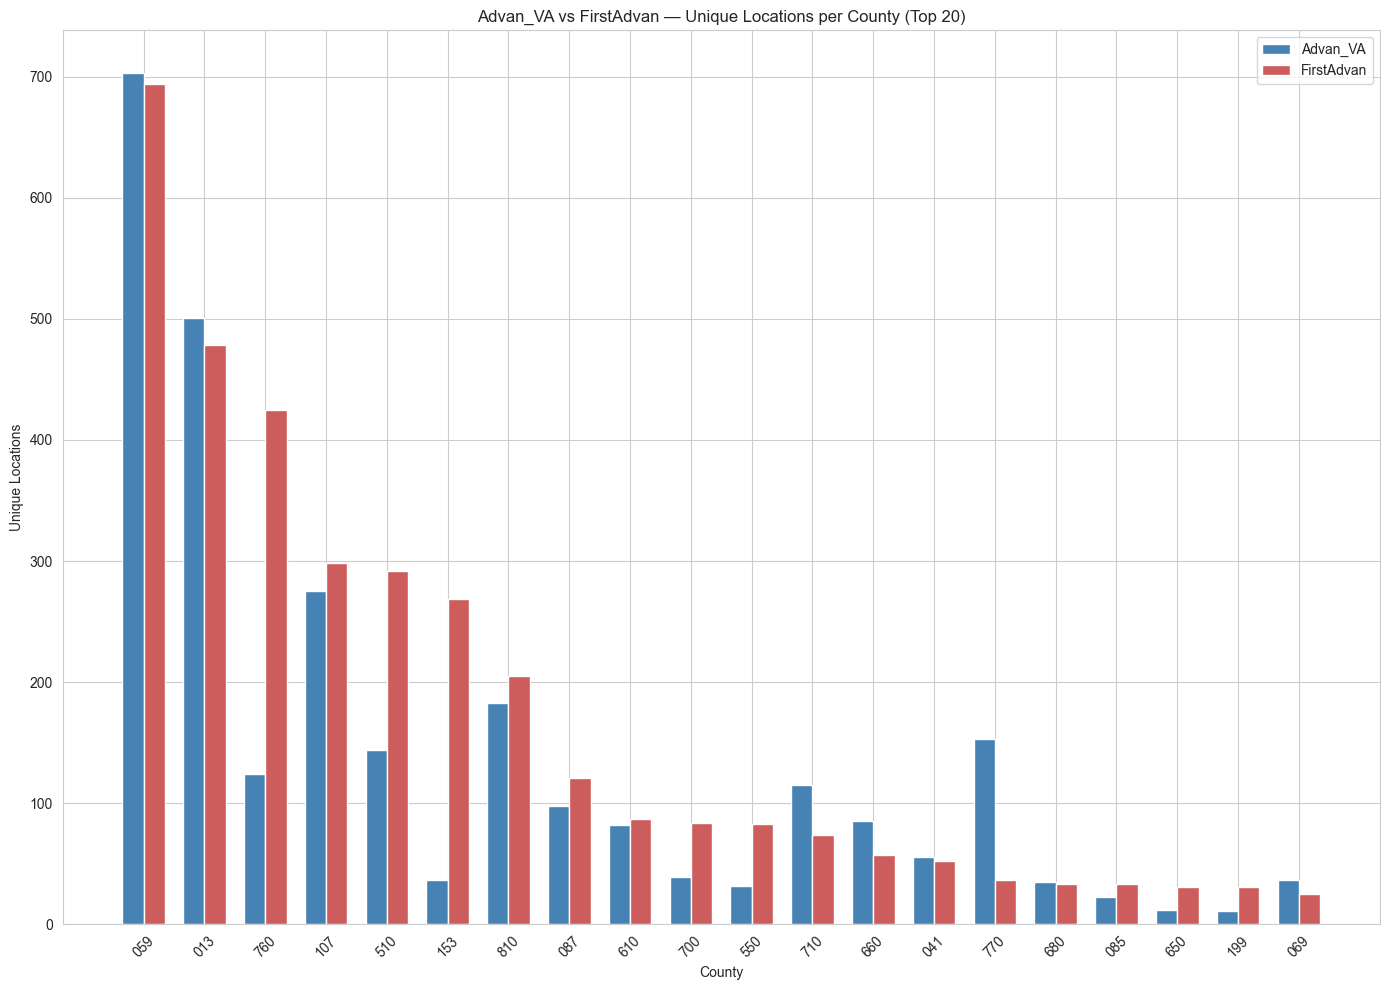

In [63]:
Advan_VA['county'] = Advan_VA['county'].astype(str).str.zfill(3)
FirstAdvan['county'] = FirstAdvan['county'].astype(str).str.zfill(3)

county_advan_va = Advan_VA.drop_duplicates(subset='placekey')['county'].value_counts()
county_FirstAdvan = FirstAdvan.drop_duplicates(subset='placekey')['county'].value_counts()

county_compare = pd.DataFrame({
    'Advan_VA': county_advan_va,
    'FirstAdvan': county_FirstAdvan
}).fillna(0).astype(int)
county_compare['diff'] = county_compare['FirstAdvan'] - county_compare['Advan_VA']

county_top = county_compare.sort_values('FirstAdvan', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(14, 10))
width = 0.35
x = range(len(county_top))
ax.bar([i - width/2 for i in x], county_top['Advan_VA'], width, label='Advan_VA', color='steelblue')
ax.bar([i + width/2 for i in x], county_top['FirstAdvan'], width, label='FirstAdvan', color='indianred')
ax.set_xticks(list(x))
ax.set_xticklabels(county_top.index, rotation=45)
ax.set_xlabel('County')
ax.set_ylabel('Unique Locations')
ax.set_title('Advan_VA vs FirstAdvan — Unique Locations per County (Top 20)')
ax.legend()
plt.tight_layout()
plt.show()

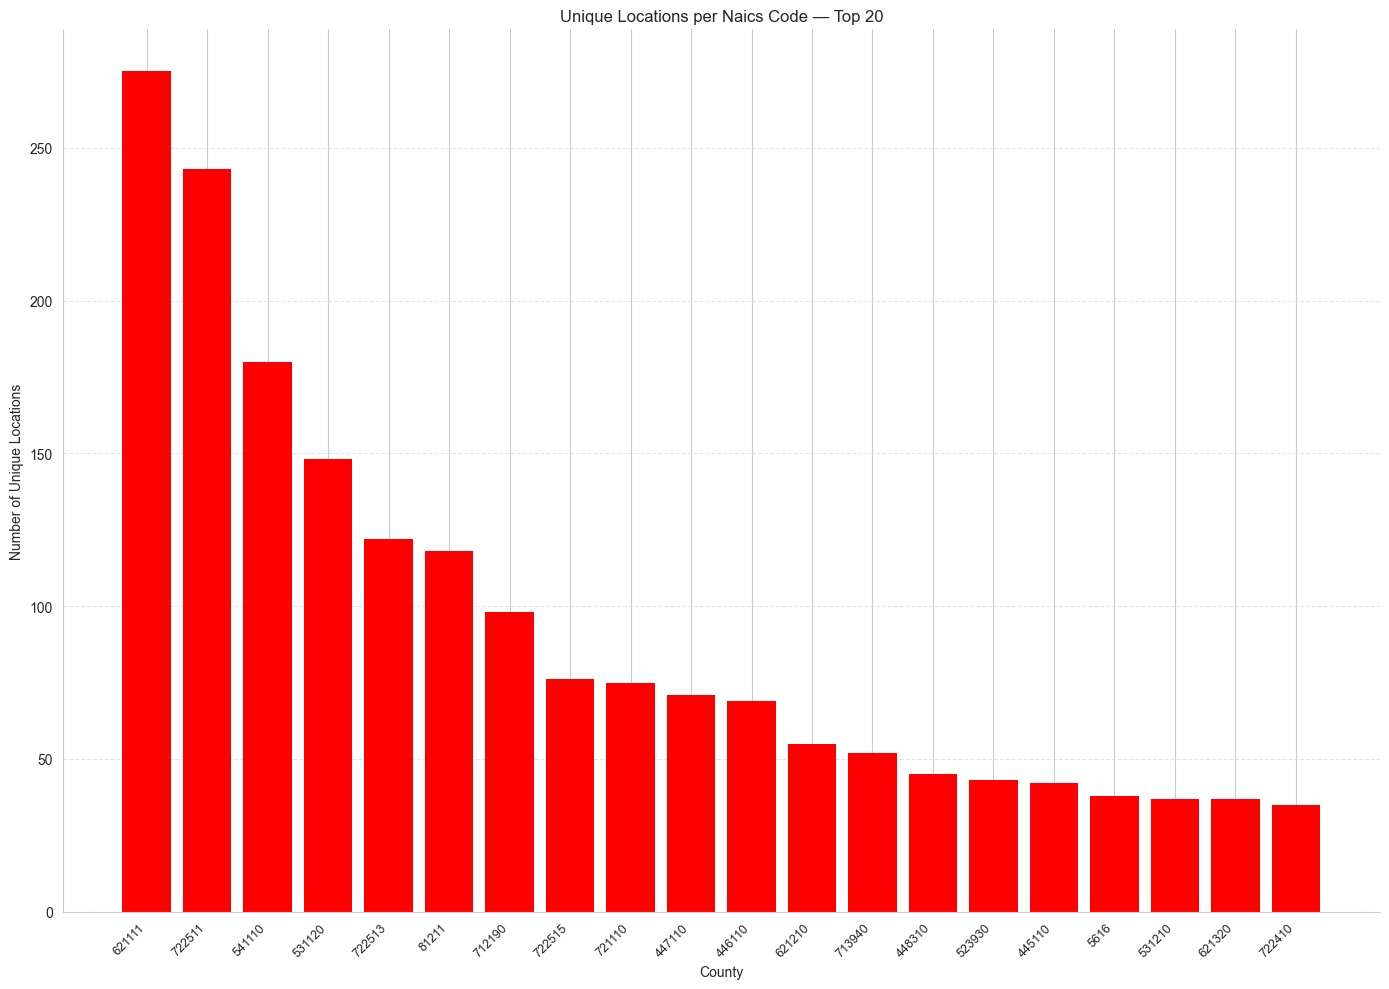

In [22]:
import matplotlib.pyplot as plt

top20 = (Advan_VA.groupby('naics_code')['placekey']
         .nunique()
         .nlargest(20)
         .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(14, 10))

ax.bar(range(len(top20)), top20.values, color='red', edgecolor='none')

ax.set_xticks(range(len(top20)))
ax.set_xticklabels(top20.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Number of Unique Locations')
ax.set_xlabel('County')
ax.set_title('Unique Locations per Naics Code — Top 20')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

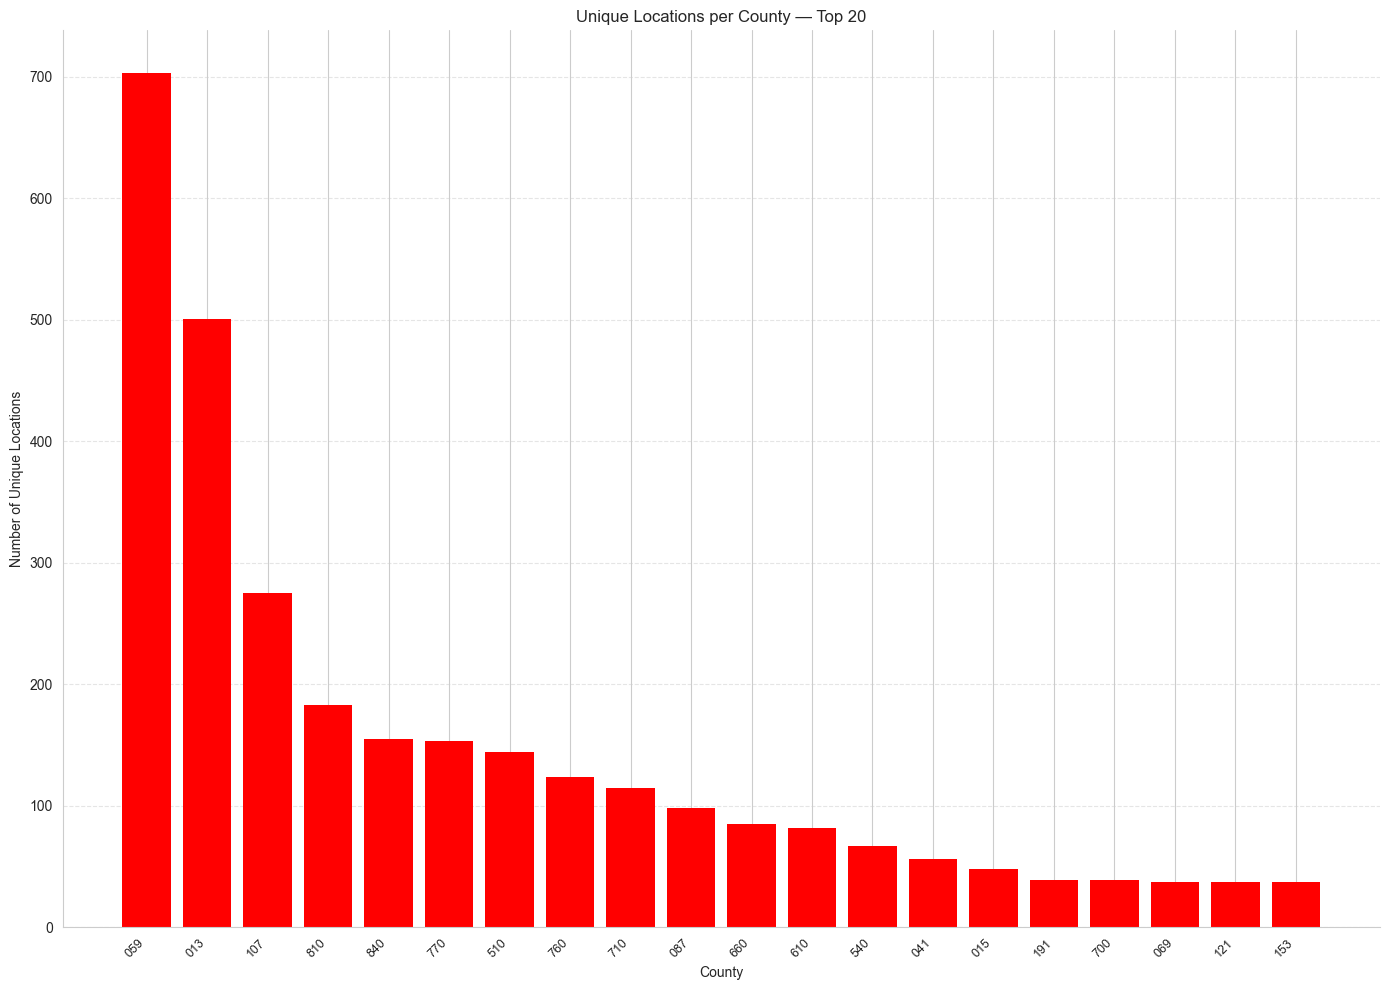

In [21]:
import matplotlib.pyplot as plt

top20 = (Advan_VA.groupby('county')['placekey']
         .nunique()
         .nlargest(20)
         .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(14, 10))

ax.bar(range(len(top20)), top20.values, color='red', edgecolor='none')

ax.set_xticks(range(len(top20)))
ax.set_xticklabels(top20.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Number of Unique Locations')
ax.set_xlabel('County')
ax.set_title('Unique Locations per County — Top 20')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Unique Advan locations in Charlottesville: 10


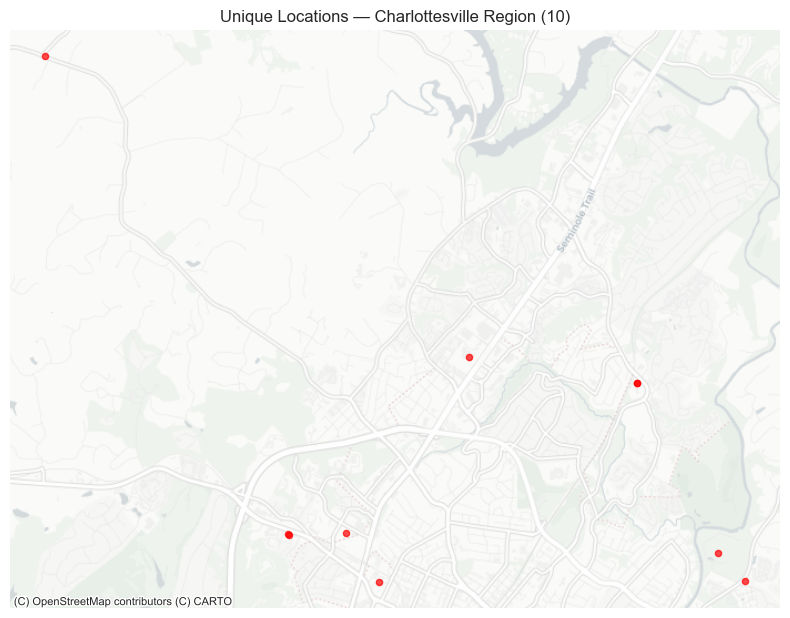

In [16]:
cville_ids = ['003']

cville = Advan_VA[
    Advan_VA['county'].isin(cville_ids)
].drop_duplicates(subset='placekey')[['placekey', 'latitude', 'longitude']]

print(f"Unique Advan locations in Charlottesville: {len(cville)}")

gdf = gpd.GeoDataFrame(cville, geometry=gpd.points_from_xy(cville['longitude'], cville['latitude']),
                        crs='EPSG:4326').to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(8, 25))
gdf.plot(ax=ax, color='red', markersize=20, alpha=0.7)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title(f'Unique Locations — Charlottesville Region ({len(cville)})')
ax.set_axis_off()
plt.tight_layout()
plt.show()

Unique Advan locations in DC Metro: 1623


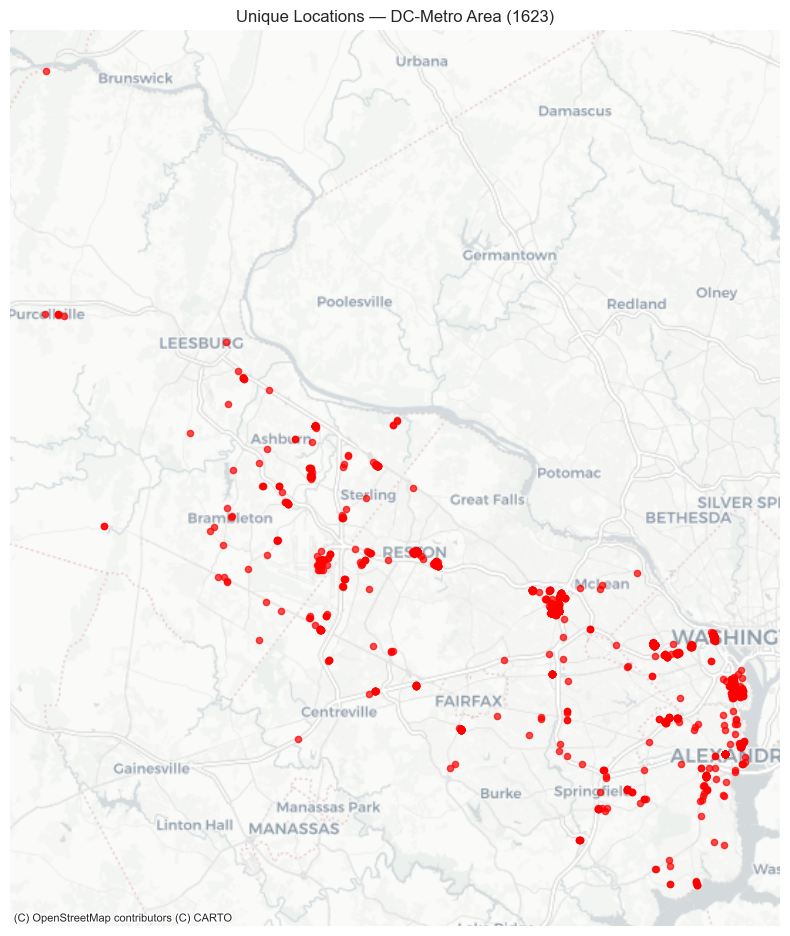

In [19]:
dc_ids = ['059', '013', '510', '107']

dc = Advan_VA[
    Advan_VA['county'].isin(dc_ids)
].drop_duplicates(subset='placekey')[['placekey', 'latitude', 'longitude']]

print(f"Unique Advan locations in DC Metro: {len(dc)}")

gdf = gpd.GeoDataFrame(dc, geometry=gpd.points_from_xy(dc['longitude'], dc['latitude']), crs='EPSG:4326').to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(8, 25))
gdf.plot(ax=ax, color='red', markersize=20, alpha=0.7)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title(f'Unique Locations — DC-Metro Area ({len(dc)})')
ax.set_axis_off()
plt.tight_layout()
plt.show()

Unique Advan locations in Richmond: 301


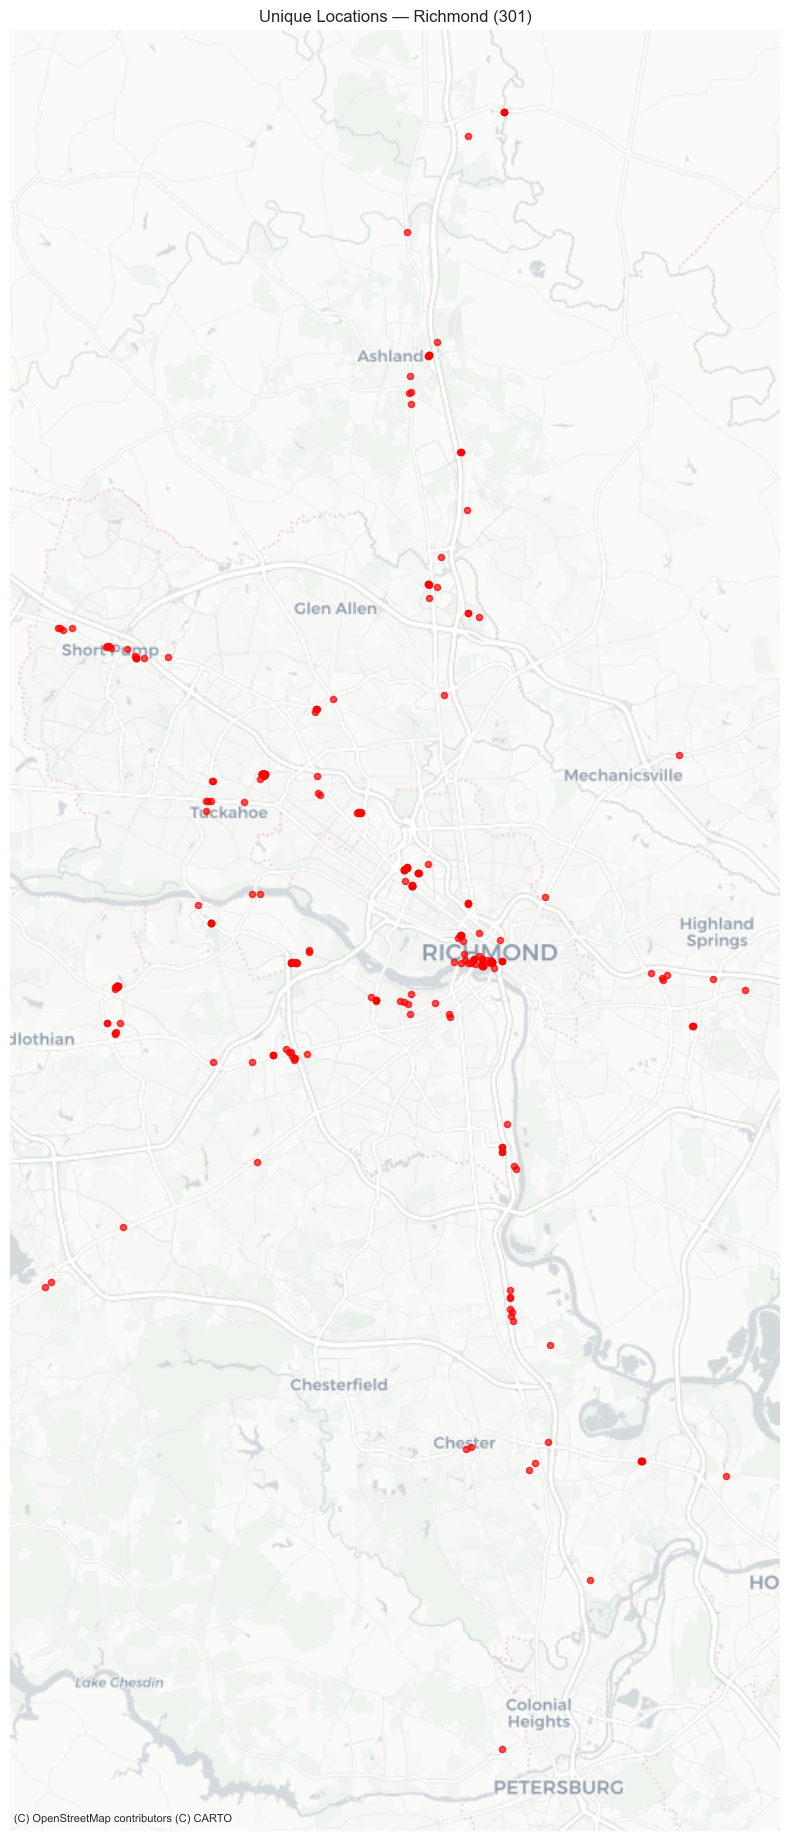

In [20]:
rich_ids = ['087', '041', '760', '085']

richmond = Advan_VA[
    Advan_VA['county'].isin(rich_ids)
].drop_duplicates(subset='placekey')[['placekey', 'latitude', 'longitude']]

print(f"Unique Advan locations in Richmond: {len(richmond)}")

gdf = gpd.GeoDataFrame(richmond, geometry=gpd.points_from_xy(richmond['longitude'], richmond['latitude']), crs='EPSG:4326').to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(8, 25))
gdf.plot(ax=ax, color='red', markersize=20, alpha=0.7)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title(f'Unique Locations — Richmond ({len(richmond)})')
ax.set_axis_off()
plt.tight_layout()
plt.show()

Unique Advan locations in Virginia Beach: 381


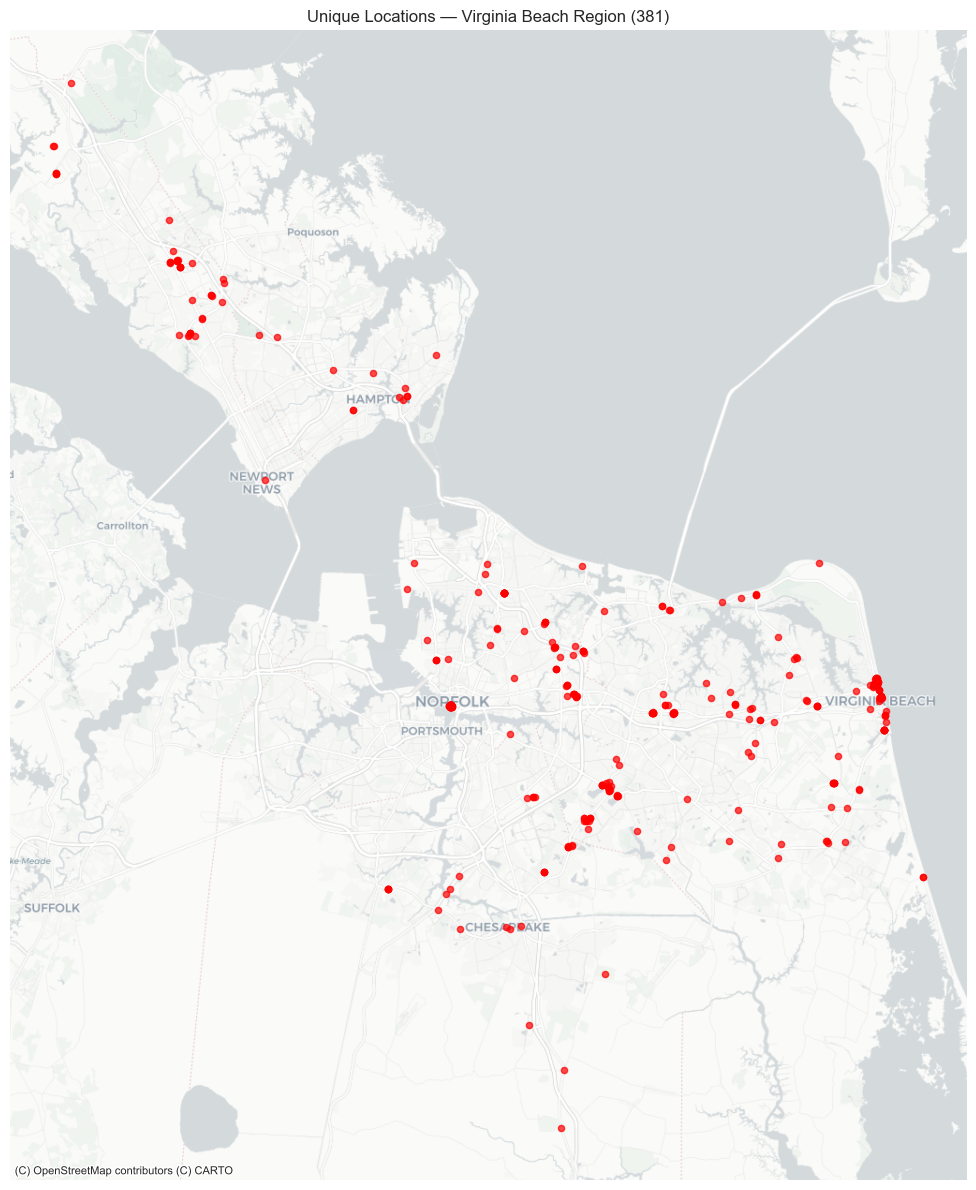

In [23]:
vb_ids = ['810', '550', '700', '650', '710']

vb = Advan_VA[
    Advan_VA['county'].isin(vb_ids)
].drop_duplicates(subset='placekey')[['placekey', 'latitude', 'longitude']]

print(f"Unique Advan locations in Virginia Beach: {len(vb)}")

gdf = gpd.GeoDataFrame(vb, geometry=gpd.points_from_xy(vb['longitude'], vb['latitude']), crs='EPSG:4326').to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 12))
gdf.plot(ax=ax, color='red', markersize=20, alpha=0.7)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title(f'Unique Locations — Virginia Beach Region ({len(vb)})')
ax.set_axis_off()
plt.tight_layout()
plt.show()

Unique Advan locations in Roanoke: 163


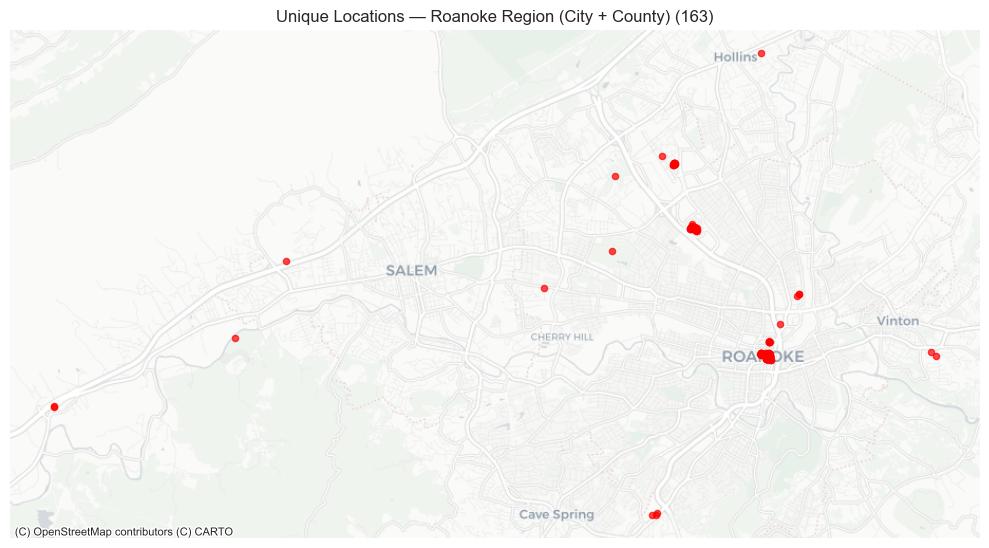

In [25]:
roanoke_county_ids = ['770', '161']

roanoke = Advan_VA[
    Advan_VA['county'].isin(roanoke_county_ids)
].drop_duplicates(subset='placekey')[['placekey', 'latitude', 'longitude']]

print(f"Unique Advan locations in Roanoke: {len(roanoke)}")

gdf = gpd.GeoDataFrame(roanoke, geometry=gpd.points_from_xy(roanoke['longitude'], roanoke['latitude']), crs='EPSG:4326').to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 12))
gdf.plot(ax=ax, color='red', markersize=20, alpha=0.7)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title(f'Unique Locations — Roanoke Region (City + County) ({len(roanoke)})')
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [32]:
Synthetic = pd.read_csv('/Users/sankalpyadava/Desktop/Biocomplexity Institute/synthetic.csv')
synthetic_agg = (Synthetic.groupby(['lid', 'latitude', 'longitude', 'admin2'])
                 .size()
                 .reset_index(name='visit_count_synthetic'))

advan_agg = (Advan_VA.groupby(['placekey', 'latitude', 'longitude', 'county'])
             .size()
             .reset_index(name='visit_count_advan'))

In [37]:
print(advan_agg['county'].dtype)
print(advan_agg['county'].unique()[:20])

print(synthetic_agg['admin2'].dtype)
print(synthetic_agg['admin2'].unique()[:20])

object
['041' '171' '083' '019' '011' '037' '117' '680' '031' '121' '197' '640'
 '770' '775' '161' '750' '155' '003' '540' '015']
int64
[131   1 810   3  15  31  41  65  79 109 125 540  29  87 137 790 820  75
 113 163]


In [39]:
dc_counties_str = ['059', '013', '510', '107']
dc_counties_int = [59, 13, 510, 107]

r = advan_agg[advan_agg['county'].isin(dc_counties_str)]
g = synthetic_agg[synthetic_agg['admin2'].isin(dc_counties_int)]

real_features = r[['latitude', 'longitude', 'visit_count_advan']].to_numpy(dtype=float)
fake_features = g[['latitude', 'longitude', 'visit_count_synthetic']].to_numpy(dtype=float)

nearest_k = 3

N, D = real_features.shape
M, _ = fake_features.shape

nbrs_R = NearestNeighbors(n_neighbors=nearest_k+1, algorithm='auto', n_jobs=-1).fit(real_features)
dist_R, _ = nbrs_R.kneighbors(real_features, nearest_k+1)

nbrs_G = NearestNeighbors(n_neighbors=nearest_k+1, algorithm='auto', n_jobs=-1).fit(fake_features)
dist_G, _ = nbrs_G.kneighbors(fake_features, nearest_k+1)

dist_RG_pairs = pairwise_distances(real_features, fake_features, n_jobs=-1)
dist_GR_pairs = pairwise_distances(fake_features, real_features, n_jobs=-1)

dist_RG, _ = nbrs_G.kneighbors(real_features, nearest_k+1)
dist_GR, _ = nbrs_R.kneighbors(fake_features, nearest_k+1)

def volume_of_unit_ball_log(d):
    return (d / 2) * np.log(pi) - loggamma((d / 2) + 1)

def cross_entropy(N, M, k, nu_k, d):
    return (1 / N) * np.sum(np.log(M) - digamma(k) + volume_of_unit_ball_log(d) + d * np.log(nu_k))

def entropy(N, k, rho_k, d):
    return (1 / N) * np.sum(np.log(N-1) - digamma(k) + volume_of_unit_ball_log(d) + d * np.log(rho_k))

def calc_precision(dist_R, dist_RG_pairs, M):
    radii_R = dist_R[:, -1]
    G_in_radius = (dist_RG_pairs <= radii_R[:, np.newaxis])
    return np.sum(np.any(G_in_radius, axis=0)) / M

def calc_density(dist_R, dist_RG_pairs, k, M):
    radii_R = dist_R[:, -1]
    G_in_radius = (dist_RG_pairs <= radii_R[:, np.newaxis])
    return np.sum(G_in_radius) / (k * M)

def calc_coverage(dist_R, dist_RG_pairs):
    radii_R = dist_R[:, -1]
    G_in_radius = (dist_RG_pairs <= radii_R[:, np.newaxis])
    return np.mean(np.any(G_in_radius, axis=1))

def compute_fd(reps1, reps2, eps=1e-6):
    mu1, sigma1 = np.mean(reps1, axis=0), np.cov(reps1, rowvar=False)
    mu2, sigma2 = np.mean(reps2, axis=0), np.cov(reps2, rowvar=False)
    diff = mu1 - mu2
    try:
        covmean = sqrtm(sigma1.dot(sigma2))
        if np.iscomplexobj(covmean):
            covmean = covmean.real
    except ValueError:
        covmean = sqrtm(sigma1 + eps * np.eye(sigma1.shape[0])).dot(sqrtm(sigma2 + eps * np.eye(sigma2.shape[0])))
        covmean = covmean.real
    return np.dot(diff, diff) + np.trace(sigma1) + np.trace(sigma2) - 2 * np.trace(covmean)

precision = calc_precision(dist_R, dist_RG_pairs, M)
recall = calc_precision(dist_G, dist_GR_pairs, N)
density = calc_density(dist_R, dist_RG_pairs, nearest_k, M)
coverage = calc_coverage(dist_R, dist_RG_pairs)

PCE = cross_entropy(M, N, nearest_k, dist_GR[:, nearest_k-1], D)
RCE = cross_entropy(N, M, nearest_k, dist_RG[:, nearest_k-1], D)
RE = entropy(N, nearest_k, dist_R[:, nearest_k], D)

fd = compute_fd(real_features, fake_features)

print(f"N = {N}, M = {M}, D = {D}")
print(f"\ndist_R:\n{dist_R}")
print(f"\ndist_G:\n{dist_G}")
print(f"\ndist_GR:\n{dist_GR}")
print(f"\ndist_RG:\n{dist_RG}")
print(f"\nprecision = {precision:.6f}")
print(f"recall    = {recall:.6f}")
print(f"density   = {density:.6f}")
print(f"coverage  = {coverage:.6f}")
print(f"\nPCE = {PCE:.6f}")
print(f"RCE = {RCE:.6f}")
print(f"RE  = {RE:.6f}")
print(f"\nfrechet_distance = {fd:.6f}")

N = 1623, M = 33117, D = 3

dist_R:
[[0.00000000e+00 1.32853303e-04 2.02080238e-02 2.02576943e-02]
 [0.00000000e+00 1.05223571e-04 1.21061968e-04 1.01980096e-03]
 [0.00000000e+00 1.61245155e-05 2.54950976e-05 2.61725047e-05]
 ...
 [0.00000000e+00 1.69034580e-02 1.81982133e-02 3.07216641e-02]
 [0.00000000e+00 2.35850257e-02 2.38594989e-02 8.26286960e-02]
 [0.00000000e+00 7.96121630e-03 8.00245494e-03 2.69690981e-02]]

dist_G:
[[0.         0.00268218 0.00440791 0.01104489]
 [0.         0.00189924 0.00286315 0.00400514]
 [0.         0.00184425 0.00189924 0.00189924]
 ...
 [0.         0.00237656 0.00594958 0.00687652]
 [0.         0.01073278 0.0166621  0.02488613]
 [0.         0.03287905 0.04171515 0.05120607]]

dist_GR:
[[ 1.21548681  1.21552605  1.26390268  1.26560501]
 [10.0004746  10.00049255 10.00049753 10.00049927]
 [ 2.00237166  2.00246128  2.00248618  2.00249487]
 ...
 [ 0.07322172  0.07328286  0.07328804  0.07336265]
 [13.00020621 13.00020655 13.00020658 13.000207  ]
 [55.00004874

In [41]:
cville_counties_str = ['003', '540']
cville_counties_int = [3, 540]

r = advan_agg[advan_agg['county'].isin(cville_counties_str)]
g = synthetic_agg[synthetic_agg['admin2'].isin(cville_counties_int)]

assert len(r) > 0, "advan_agg filter returned no rows — check county code format"
assert len(g) > 0, "synthetic_agg filter returned no rows — check admin2 code format"

real_features = r[['latitude', 'longitude', 'visit_count_advan']].to_numpy(dtype=float)
fake_features = g[['latitude', 'longitude', 'visit_count_synthetic']].to_numpy(dtype=float)

nearest_k = 3

N, D = real_features.shape
M, _ = fake_features.shape

nbrs_R = NearestNeighbors(n_neighbors=nearest_k+1, algorithm='auto', n_jobs=-1).fit(real_features)
dist_R, _ = nbrs_R.kneighbors(real_features, nearest_k+1)

nbrs_G = NearestNeighbors(n_neighbors=nearest_k+1, algorithm='auto', n_jobs=-1).fit(fake_features)
dist_G, _ = nbrs_G.kneighbors(fake_features, nearest_k+1)

dist_RG_pairs = pairwise_distances(real_features, fake_features, n_jobs=-1)
dist_GR_pairs = pairwise_distances(fake_features, real_features, n_jobs=-1)

dist_RG, _ = nbrs_G.kneighbors(real_features, nearest_k+1)
dist_GR, _ = nbrs_R.kneighbors(fake_features, nearest_k+1)

def volume_of_unit_ball_log(d):
    return (d / 2) * np.log(pi) - loggamma((d / 2) + 1)

def cross_entropy(N, M, k, nu_k, d):
    return (1 / N) * np.sum(np.log(M) - digamma(k) + volume_of_unit_ball_log(d) + d * np.log(nu_k))

def entropy(N, k, rho_k, d):
    return (1 / N) * np.sum(np.log(N-1) - digamma(k) + volume_of_unit_ball_log(d) + d * np.log(rho_k))

def calc_precision(dist_R, dist_RG_pairs, M):
    radii_R = dist_R[:, -1]
    G_in_radius = (dist_RG_pairs <= radii_R[:, np.newaxis])
    return np.sum(np.any(G_in_radius, axis=0)) / M

def calc_density(dist_R, dist_RG_pairs, k, M):
    radii_R = dist_R[:, -1]
    G_in_radius = (dist_RG_pairs <= radii_R[:, np.newaxis])
    return np.sum(G_in_radius) / (k * M)

def calc_coverage(dist_R, dist_RG_pairs):
    radii_R = dist_R[:, -1]
    G_in_radius = (dist_RG_pairs <= radii_R[:, np.newaxis])
    return np.mean(np.any(G_in_radius, axis=1))

def compute_fd(reps1, reps2, eps=1e-6):
    mu1, sigma1 = np.mean(reps1, axis=0), np.cov(reps1, rowvar=False)
    mu2, sigma2 = np.mean(reps2, axis=0), np.cov(reps2, rowvar=False)
    diff = mu1 - mu2
    try:
        covmean = sqrtm(sigma1.dot(sigma2))
        if np.iscomplexobj(covmean):
            covmean = covmean.real
    except ValueError:
        covmean = sqrtm(sigma1 + eps * np.eye(sigma1.shape[0])).dot(sqrtm(sigma2 + eps * np.eye(sigma2.shape[0])))
        covmean = covmean.real
    return np.dot(diff, diff) + np.trace(sigma1) + np.trace(sigma2) - 2 * np.trace(covmean)

precision = calc_precision(dist_R, dist_RG_pairs, M)
recall = calc_precision(dist_G, dist_GR_pairs, N)
density = calc_density(dist_R, dist_RG_pairs, nearest_k, M)
coverage = calc_coverage(dist_R, dist_RG_pairs)

PCE = cross_entropy(M, N, nearest_k, dist_GR[:, nearest_k-1], D)
RCE = cross_entropy(N, M, nearest_k, dist_RG[:, nearest_k-1], D)
RE = entropy(N, nearest_k, dist_R[:, nearest_k], D)

fd = compute_fd(real_features, fake_features)

print(f"N = {N}, M = {M}, D = {D}")
print(f"\ndist_R:\n{dist_R}")
print(f"\ndist_G:\n{dist_G}")
print(f"\ndist_GR:\n{dist_GR}")
print(f"\ndist_RG:\n{dist_RG}")
print(f"\nprecision = {precision:.6f}")
print(f"recall    = {recall:.6f}")
print(f"density   = {density:.6f}")
print(f"coverage  = {coverage:.6f}")
print(f"\nPCE = {PCE:.6f}")
print(f"RCE = {RCE:.6f}")
print(f"RE  = {RE:.6f}")
print(f"\nfrechet_distance = {fd:.6f}")

N = 77, M = 3351, D = 3

dist_R:
[[0.00000000e+00 5.46151664e-03 1.00972465e-02 1.46094888e-02]
 [0.00000000e+00 4.60615675e-03 5.52425995e-03 5.83381608e-03]
 [0.00000000e+00 7.28354309e-05 8.85453827e-03 1.99899319e-02]
 [0.00000000e+00 4.99043936e-03 5.00299041e-03 5.01666313e-03]
 [0.00000000e+00 4.46806367e-03 4.54733548e-03 4.57446172e-03]
 [0.00000000e+00 1.76543762e-03 1.77583473e-03 1.77999157e-03]
 [0.00000000e+00 6.93901827e-02 6.94615419e-02 7.44019848e-02]
 [0.00000000e+00 7.28354309e-05 8.80495866e-03 1.99267686e-02]
 [0.00000000e+00 1.11803399e-05 1.84390889e-05 1.76543762e-03]
 [0.00000000e+00 1.11803399e-05 1.60312195e-05 1.77583473e-03]
 [0.00000000e+00 1.60312195e-05 1.84390889e-05 1.77999157e-03]
 [0.00000000e+00 2.22189694e-03 3.85692689e-03 3.92341943e-03]
 [0.00000000e+00 2.15363066e-03 2.83159761e-03 2.83523615e-03]
 [0.00000000e+00 1.36320358e-03 1.59458741e-03 1.84415536e-03]
 [0.00000000e+00 1.21655251e-04 2.25077764e-04 2.47477272e-04]
 [0.00000000e+00 2.000

In [43]:
richmond_counties_str = ['087', '041', '760', '085']
richmond_counties_int = [87, 41, 760, 85]

r = advan_agg[advan_agg['county'].isin(richmond_counties_str)]
g = synthetic_agg[synthetic_agg['admin2'].isin(richmond_counties_int)]

assert len(r) > 0, "advan_agg filter returned no rows — check county code format"
assert len(g) > 0, "synthetic_agg filter returned no rows — check admin2 code format"

real_features = r[['latitude', 'longitude', 'visit_count_advan']].to_numpy(dtype=float)
fake_features = g[['latitude', 'longitude', 'visit_count_synthetic']].to_numpy(dtype=float)

nearest_k = 3

N, D = real_features.shape
M, _ = fake_features.shape

nbrs_R = NearestNeighbors(n_neighbors=nearest_k+1, algorithm='auto', n_jobs=-1).fit(real_features)
dist_R, _ = nbrs_R.kneighbors(real_features, nearest_k+1)

nbrs_G = NearestNeighbors(n_neighbors=nearest_k+1, algorithm='auto', n_jobs=-1).fit(fake_features)
dist_G, _ = nbrs_G.kneighbors(fake_features, nearest_k+1)

dist_RG_pairs = pairwise_distances(real_features, fake_features, n_jobs=-1)
dist_GR_pairs = pairwise_distances(fake_features, real_features, n_jobs=-1)

dist_RG, _ = nbrs_G.kneighbors(real_features, nearest_k+1)
dist_GR, _ = nbrs_R.kneighbors(fake_features, nearest_k+1)

def volume_of_unit_ball_log(d):
    return (d / 2) * np.log(pi) - loggamma((d / 2) + 1)

def cross_entropy(N, M, k, nu_k, d):
    return (1 / N) * np.sum(np.log(M) - digamma(k) + volume_of_unit_ball_log(d) + d * np.log(nu_k))

def entropy(N, k, rho_k, d):
    return (1 / N) * np.sum(np.log(N-1) - digamma(k) + volume_of_unit_ball_log(d) + d * np.log(rho_k))

def calc_precision(dist_R, dist_RG_pairs, M):
    radii_R = dist_R[:, -1]
    G_in_radius = (dist_RG_pairs <= radii_R[:, np.newaxis])
    return np.sum(np.any(G_in_radius, axis=0)) / M

def calc_density(dist_R, dist_RG_pairs, k, M):
    radii_R = dist_R[:, -1]
    G_in_radius = (dist_RG_pairs <= radii_R[:, np.newaxis])
    return np.sum(G_in_radius) / (k * M)

def calc_coverage(dist_R, dist_RG_pairs):
    radii_R = dist_R[:, -1]
    G_in_radius = (dist_RG_pairs <= radii_R[:, np.newaxis])
    return np.mean(np.any(G_in_radius, axis=1))

def compute_fd(reps1, reps2, eps=1e-6):
    mu1, sigma1 = np.mean(reps1, axis=0), np.cov(reps1, rowvar=False)
    mu2, sigma2 = np.mean(reps2, axis=0), np.cov(reps2, rowvar=False)
    diff = mu1 - mu2
    try:
        covmean = sqrtm(sigma1.dot(sigma2))
        if np.iscomplexobj(covmean):
            covmean = covmean.real
    except ValueError:
        covmean = sqrtm(sigma1 + eps * np.eye(sigma1.shape[0])).dot(sqrtm(sigma2 + eps * np.eye(sigma2.shape[0])))
        covmean = covmean.real
    return np.dot(diff, diff) + np.trace(sigma1) + np.trace(sigma2) - 2 * np.trace(covmean)

precision = calc_precision(dist_R, dist_RG_pairs, M)
recall = calc_precision(dist_G, dist_GR_pairs, N)
density = calc_density(dist_R, dist_RG_pairs, nearest_k, M)
coverage = calc_coverage(dist_R, dist_RG_pairs)

PCE = cross_entropy(M, N, nearest_k, dist_GR[:, nearest_k-1], D)
RCE = cross_entropy(N, M, nearest_k, dist_RG[:, nearest_k-1], D)
RE = entropy(N, nearest_k, dist_R[:, nearest_k], D)

fd = compute_fd(real_features, fake_features)

print(f"N = {N}, M = {M}, D = {D}")
print(f"\ndist_R:\n{dist_R}")
print(f"\ndist_G:\n{dist_G}")
print(f"\ndist_GR:\n{dist_GR}")
print(f"\ndist_RG:\n{dist_RG}")
print(f"\nprecision = {precision:.6f}")
print(f"recall    = {recall:.6f}")
print(f"density   = {density:.6f}")
print(f"coverage  = {coverage:.6f}")
print(f"\nPCE = {PCE:.6f}")
print(f"RCE = {RCE:.6f}")
print(f"RE  = {RE:.6f}")
print(f"\nfrechet_distance = {fd:.6f}")

N = 301, M = 21655, D = 3

dist_R:
[[0.         0.0754231  0.10480476 0.10760351]
 [0.         0.00153646 0.00220364 0.0026288 ]
 [0.         0.00037075 0.00293319 0.00415465]
 ...
 [0.         0.00620377 0.00993514 0.01157322]
 [0.         0.00374206 0.00573523 0.00620377]
 [0.         0.03055189 0.04222117 0.1028133 ]]

dist_G:
[[0.         0.0502163  0.05867782 0.06349864]
 [0.         0.01058144 0.06513942 0.06896992]
 [0.         0.00874748 0.05730384 0.0574109 ]
 ...
 [0.         0.         0.00726122 0.00726122]
 [0.         0.01483664 0.01726343 0.01768597]
 [0.         0.         0.00726122 0.00726122]]

dist_GR:
[[ 1.17455627  1.17556029  1.17691154  1.18059649]
 [ 1.02088777  1.02187895  1.0232435   1.02681851]
 [ 0.95264968  1.01894737  1.02031225  1.03565202]
 ...
 [ 0.02065777  0.02345487  0.02796458  0.0285668 ]
 [15.0000264  15.00007538 15.00013128 15.00028265]
 [ 0.02065777  0.02345487  0.02796458  0.0285668 ]]

dist_RG:
[[5.60506364e-05 2.21120514e-03 3.46252884e-03 3

In [45]:
vb_counties_str = ['810', '550', '700', '650', '710']
vb_counties_int = [810, 550, 700, 650, 710]

r = advan_agg[advan_agg['county'].isin(vb_counties_str)]
g = synthetic_agg[synthetic_agg['admin2'].isin(vb_counties_int)]

assert len(r) > 0, "advan_agg filter returned no rows — check county code format"
assert len(g) > 0, "synthetic_agg filter returned no rows — check admin2 code format"

real_features = r[['latitude', 'longitude', 'visit_count_advan']].to_numpy(dtype=float)
fake_features = g[['latitude', 'longitude', 'visit_count_synthetic']].to_numpy(dtype=float)

nearest_k = 3

N, D = real_features.shape
M, _ = fake_features.shape

nbrs_R = NearestNeighbors(n_neighbors=nearest_k+1, algorithm='auto', n_jobs=-1).fit(real_features)
dist_R, _ = nbrs_R.kneighbors(real_features, nearest_k+1)

nbrs_G = NearestNeighbors(n_neighbors=nearest_k+1, algorithm='auto', n_jobs=-1).fit(fake_features)
dist_G, _ = nbrs_G.kneighbors(fake_features, nearest_k+1)

dist_RG_pairs = pairwise_distances(real_features, fake_features, n_jobs=-1)
dist_GR_pairs = pairwise_distances(fake_features, real_features, n_jobs=-1)

dist_RG, _ = nbrs_G.kneighbors(real_features, nearest_k+1)
dist_GR, _ = nbrs_R.kneighbors(fake_features, nearest_k+1)

def volume_of_unit_ball_log(d):
    return (d / 2) * np.log(pi) - loggamma((d / 2) + 1)

def cross_entropy(N, M, k, nu_k, d):
    return (1 / N) * np.sum(np.log(M) - digamma(k) + volume_of_unit_ball_log(d) + d * np.log(nu_k))

def entropy(N, k, rho_k, d):
    return (1 / N) * np.sum(np.log(N-1) - digamma(k) + volume_of_unit_ball_log(d) + d * np.log(rho_k))

def calc_precision(dist_R, dist_RG_pairs, M):
    radii_R = dist_R[:, -1]
    G_in_radius = (dist_RG_pairs <= radii_R[:, np.newaxis])
    return np.sum(np.any(G_in_radius, axis=0)) / M

def calc_density(dist_R, dist_RG_pairs, k, M):
    radii_R = dist_R[:, -1]
    G_in_radius = (dist_RG_pairs <= radii_R[:, np.newaxis])
    return np.sum(G_in_radius) / (k * M)

def calc_coverage(dist_R, dist_RG_pairs):
    radii_R = dist_R[:, -1]
    G_in_radius = (dist_RG_pairs <= radii_R[:, np.newaxis])
    return np.mean(np.any(G_in_radius, axis=1))

def compute_fd(reps1, reps2, eps=1e-6):
    mu1, sigma1 = np.mean(reps1, axis=0), np.cov(reps1, rowvar=False)
    mu2, sigma2 = np.mean(reps2, axis=0), np.cov(reps2, rowvar=False)
    diff = mu1 - mu2
    try:
        covmean = sqrtm(sigma1.dot(sigma2))
        if np.iscomplexobj(covmean):
            covmean = covmean.real
    except ValueError:
        covmean = sqrtm(sigma1 + eps * np.eye(sigma1.shape[0])).dot(sqrtm(sigma2 + eps * np.eye(sigma2.shape[0])))
        covmean = covmean.real
    return np.dot(diff, diff) + np.trace(sigma1) + np.trace(sigma2) - 2 * np.trace(covmean)

precision = calc_precision(dist_R, dist_RG_pairs, M)
recall = calc_precision(dist_G, dist_GR_pairs, N)
density = calc_density(dist_R, dist_RG_pairs, nearest_k, M)
coverage = calc_coverage(dist_R, dist_RG_pairs)

PCE = cross_entropy(M, N, nearest_k, dist_GR[:, nearest_k-1], D)
RCE = cross_entropy(N, M, nearest_k, dist_RG[:, nearest_k-1], D)
RE = entropy(N, nearest_k, dist_R[:, nearest_k], D)

fd = compute_fd(real_features, fake_features)

print(f"N = {N}, M = {M}, D = {D}")
print(f"\ndist_R:\n{dist_R}")
print(f"\ndist_G:\n{dist_G}")
print(f"\ndist_GR:\n{dist_GR}")
print(f"\ndist_RG:\n{dist_RG}")
print(f"\nprecision = {precision:.6f}")
print(f"recall    = {recall:.6f}")
print(f"density   = {density:.6f}")
print(f"coverage  = {coverage:.6f}")
print(f"\nPCE = {PCE:.6f}")
print(f"RCE = {RCE:.6f}")
print(f"RE  = {RE:.6f}")
print(f"\nfrechet_distance = {fd:.6f}")

N = 381, M = 25396, D = 3

dist_R:
[[0.00000000e+00 8.27647268e-05 6.06730921e-02 6.96970420e-02]
 [0.00000000e+00 8.27567719e-03 3.60437651e-02 3.69457733e-02]
 [0.00000000e+00 1.39281568e-02 1.40112836e-02 1.40156338e-02]
 ...
 [0.00000000e+00 7.63112154e-03 7.63833313e-03 8.42595069e-03]
 [0.00000000e+00 4.71416990e-02 5.76389225e-02 6.34132178e-02]
 [0.00000000e+00 8.27567719e-03 3.27214565e-02 3.37027121e-02]]

dist_G:
[[0.         0.00150261 0.0061988  0.0164719 ]
 [0.         0.00518162 0.20919281 0.30064423]
 [0.         0.01095947 0.17694626 0.18022295]
 ...
 [0.         0.         0.         0.00493722]
 [0.         0.00923439 0.01647763 0.01791794]
 [0.         0.08670904 0.10741843 0.15196783]]

dist_GR:
[[1.23429871 1.23469493 1.23473631 1.23482464]
 [2.2338012  2.23439949 2.2386534  2.24218162]
 [3.29554139 3.29555866 3.30021503 3.30025906]
 ...
 [0.11926075 0.14987693 0.15362874 0.15540022]
 [0.90731378 0.90732985 0.9095142  0.913672  ]
 [1.03669174 1.0374712  1.04186243

In [47]:
roanoke_counties_str = ['161', '770']
roanoke_counties_int = [161, 770]

r = advan_agg[advan_agg['county'].isin(roanoke_counties_str)]
g = synthetic_agg[synthetic_agg['admin2'].isin(roanoke_counties_int)]

assert len(r) > 0, "advan_agg filter returned no rows — check county code format"
assert len(g) > 0, "synthetic_agg filter returned no rows — check admin2 code format"

real_features = r[['latitude', 'longitude', 'visit_count_advan']].to_numpy(dtype=float)
fake_features = g[['latitude', 'longitude', 'visit_count_synthetic']].to_numpy(dtype=float)

nearest_k = 3

N, D = real_features.shape
M, _ = fake_features.shape

nbrs_R = NearestNeighbors(n_neighbors=nearest_k+1, algorithm='auto', n_jobs=-1).fit(real_features)
dist_R, _ = nbrs_R.kneighbors(real_features, nearest_k+1)

nbrs_G = NearestNeighbors(n_neighbors=nearest_k+1, algorithm='auto', n_jobs=-1).fit(fake_features)
dist_G, _ = nbrs_G.kneighbors(fake_features, nearest_k+1)

dist_RG_pairs = pairwise_distances(real_features, fake_features, n_jobs=-1)
dist_GR_pairs = pairwise_distances(fake_features, real_features, n_jobs=-1)

dist_RG, _ = nbrs_G.kneighbors(real_features, nearest_k+1)
dist_GR, _ = nbrs_R.kneighbors(fake_features, nearest_k+1)

def volume_of_unit_ball_log(d):
    return (d / 2) * np.log(pi) - loggamma((d / 2) + 1)

def cross_entropy(N, M, k, nu_k, d):
    return (1 / N) * np.sum(np.log(M) - digamma(k) + volume_of_unit_ball_log(d) + d * np.log(nu_k))

def entropy(N, k, rho_k, d):
    return (1 / N) * np.sum(np.log(N-1) - digamma(k) + volume_of_unit_ball_log(d) + d * np.log(rho_k))

def calc_precision(dist_R, dist_RG_pairs, M):
    radii_R = dist_R[:, -1]
    G_in_radius = (dist_RG_pairs <= radii_R[:, np.newaxis])
    return np.sum(np.any(G_in_radius, axis=0)) / M

def calc_density(dist_R, dist_RG_pairs, k, M):
    radii_R = dist_R[:, -1]
    G_in_radius = (dist_RG_pairs <= radii_R[:, np.newaxis])
    return np.sum(G_in_radius) / (k * M)

def calc_coverage(dist_R, dist_RG_pairs):
    radii_R = dist_R[:, -1]
    G_in_radius = (dist_RG_pairs <= radii_R[:, np.newaxis])
    return np.mean(np.any(G_in_radius, axis=1))

def compute_fd(reps1, reps2, eps=1e-6):
    mu1, sigma1 = np.mean(reps1, axis=0), np.cov(reps1, rowvar=False)
    mu2, sigma2 = np.mean(reps2, axis=0), np.cov(reps2, rowvar=False)
    diff = mu1 - mu2
    try:
        covmean = sqrtm(sigma1.dot(sigma2))
        if np.iscomplexobj(covmean):
            covmean = covmean.real
    except ValueError:
        covmean = sqrtm(sigma1 + eps * np.eye(sigma1.shape[0])).dot(sqrtm(sigma2 + eps * np.eye(sigma2.shape[0])))
        covmean = covmean.real
    return np.dot(diff, diff) + np.trace(sigma1) + np.trace(sigma2) - 2 * np.trace(covmean)

precision = calc_precision(dist_R, dist_RG_pairs, M)
recall = calc_precision(dist_G, dist_GR_pairs, N)
density = calc_density(dist_R, dist_RG_pairs, nearest_k, M)
coverage = calc_coverage(dist_R, dist_RG_pairs)

PCE = cross_entropy(M, N, nearest_k, dist_GR[:, nearest_k-1], D)
RCE = cross_entropy(N, M, nearest_k, dist_RG[:, nearest_k-1], D)
RE = entropy(N, nearest_k, dist_R[:, nearest_k], D)

fd = compute_fd(real_features, fake_features)

print(f"N = {N}, M = {M}, D = {D}")
print(f"\ndist_R:\n{dist_R}")
print(f"\ndist_G:\n{dist_G}")
print(f"\ndist_GR:\n{dist_GR}")
print(f"\ndist_RG:\n{dist_RG}")
print(f"\nprecision = {precision:.6f}")
print(f"recall    = {recall:.6f}")
print(f"density   = {density:.6f}")
print(f"coverage  = {coverage:.6f}")
print(f"\nPCE = {PCE:.6f}")
print(f"RCE = {RCE:.6f}")
print(f"RE  = {RE:.6f}")
print(f"\nfrechet_distance = {fd:.6f}")

N = 163, M = 3732, D = 3

dist_R:
[[0.00000000e+00 2.40352492e-02 3.69997311e-02 5.00478097e-02]
 [0.00000000e+00 2.58362444e-02 8.40547392e-02 8.41403673e-02]
 [0.00000000e+00 1.80427271e-04 2.29923900e-04 2.84022886e-04]
 [0.00000000e+00 6.12943717e-05 9.05538514e-05 1.28144450e-04]
 [0.00000000e+00 4.00596557e-02 4.01982918e-02 4.02034212e-02]
 [0.00000000e+00 9.43890884e-04 9.79147588e-04 9.07194224e-03]
 [0.00000000e+00 4.21900462e-05 4.56508488e-05 1.08577162e-04]
 [0.00000000e+00 1.24679589e-04 1.77792013e-04 1.78440466e-04]
 [0.00000000e+00 2.28035085e-05 4.21900462e-05 9.26552751e-05]
 [0.00000000e+00 3.50000000e-05 7.13672894e-04 7.75795076e-04]
 [0.00000000e+00 4.45533388e-05 5.00899191e-05 6.02079729e-05]
 [0.00000000e+00 1.70293864e-05 2.12132034e-05 2.01645729e-04]
 [0.00000000e+00 1.58240324e-04 1.62052461e-04 1.68074388e-04]
 [0.00000000e+00 3.50000000e-05 7.14030812e-04 7.79939100e-04]
 [0.00000000e+00 1.70293864e-05 1.88679623e-05 2.07183494e-04]
 [0.00000000e+00 1.24